<a href="https://colab.research.google.com/github/Innocent-Gershon/Summative-assignment---MLOP/blob/main/MY_SUMMATIVE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow matplotlib seaborn scikit-learn numpy pandas Pillow kaggle -q

#Data Acquisition

In [2]:
from google.colab import drive
drive.mount('/content/drive')

#Verify file existence
!ls "/content/drive/MyDrive/MLOP-Assignment/"

!unzip -q "/content/drive/MyDrive/MLOP-Assignment/archive (1).zip" -d /content/data/

print('Dataset ready!')
!ls /content/data/

Mounted at /content/drive
'archive (1).zip'
Dataset ready!
'Multi-class Weather Dataset'


## Import Necessary Libraries

In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuration
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 25
NUM_CLASSES = 6

TRAIN_DIR = '/content/data/dataset/train'
TEST_DIR  = '/content/data/dataset/test'

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.19.0
GPU available: False


## Exploratory Data Analysis (EDA)

In [7]:
BASE_DIR = '/content/data/Multi-class Weather Dataset/'

# Let's inspect the contents of the unzipped directory to verify the actual structure
print('Contents of ' + BASE_DIR + ' :')
!ls "{BASE_DIR}"

def get_class_counts(directory):
    counts = {}
    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

# For EDA purposes, we'll get counts from the base directory for all classes.
# A proper train/test split will need to be implemented later.
all_counts = get_class_counts(BASE_DIR)

print('\nTotal image distribution across all classes:')
for cls, count in all_counts.items():
    print(f'  {cls}: {count} images')

print(f'\nTotal images in dataset: {sum(all_counts.values())}')

# Placeholder for TRAIN_DIR and TEST_DIR, will be properly set after splitting
TRAIN_DIR = None
TEST_DIR  = None

Contents of /content/data/Multi-class Weather Dataset/ :
Cloudy	Rain  Shine  Sunrise

Total image distribution across all classes:
  Cloudy: 300 images
  Rain: 215 images
  Shine: 253 images
  Sunrise: 357 images

Total images in dataset: 1125


/tmp/ipykernel_7449/2264799842.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(all_counts.keys()), y=list(all_counts.values()), palette='viridis')


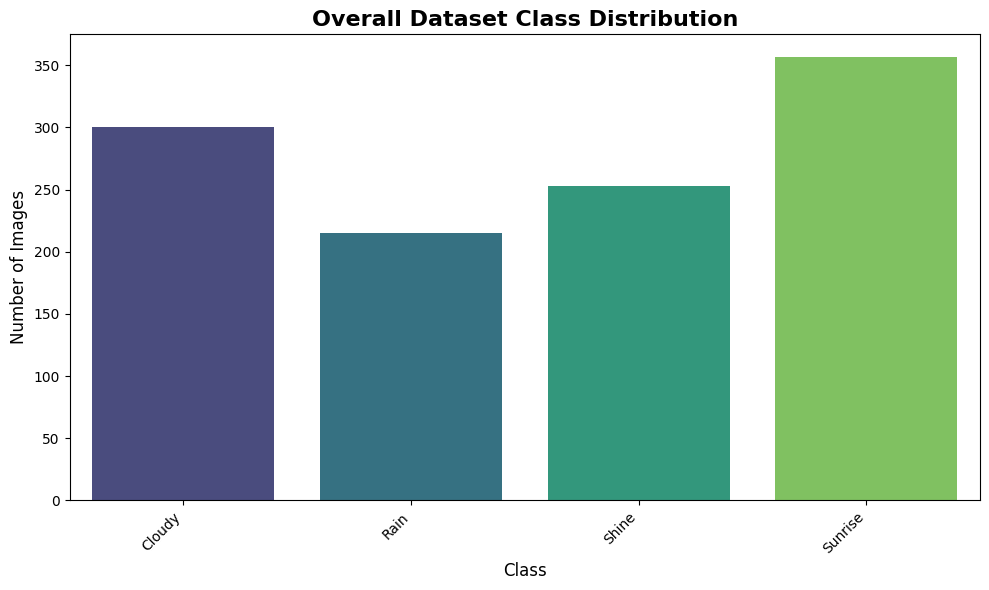


 Interpretation: The dataset appears to be reasonably balanced across the available weather classes.


In [9]:
# Feature 1: Class Distribution Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=list(all_counts.keys()), y=list(all_counts.values()), palette='viridis')
plt.title('Overall Dataset Class Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Interpretation: The dataset appears to be reasonably balanced across the available weather classes.')

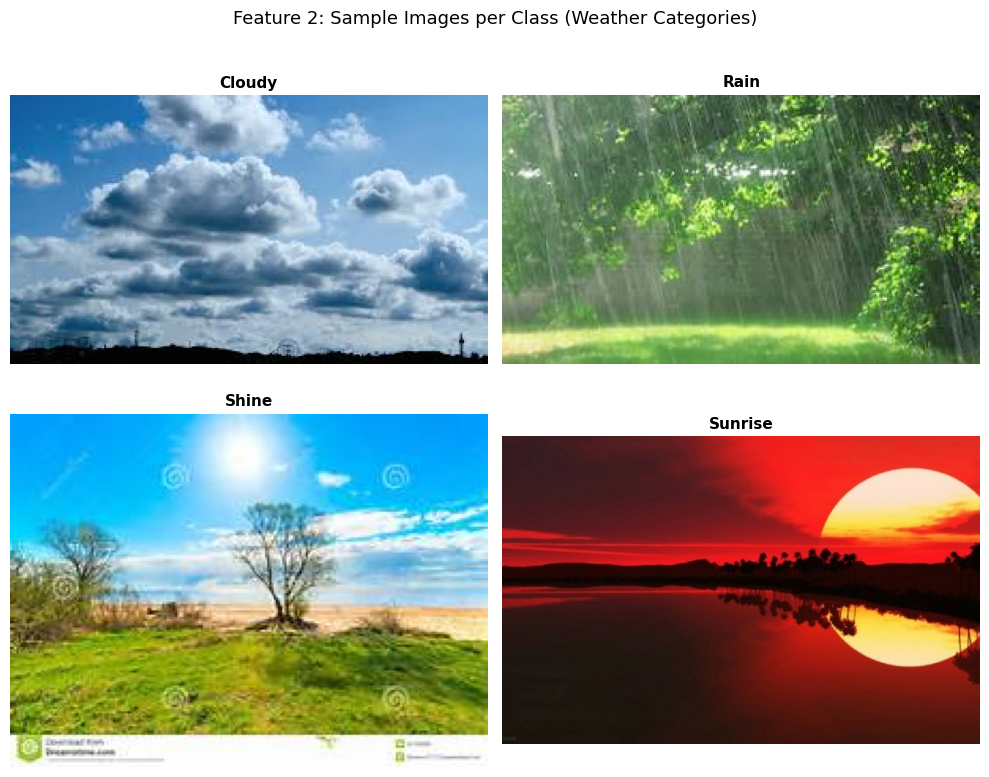


 Interpretation: These are sample images from each weather category.
The images show distinct visual characteristics for Cloudy, Rain, Shine, and Sunrise conditions.
These visual cues will be used by the CNN model to distinguish between different weather types.


In [12]:
# Feature 2: Sample Images per Class
fig, axes = plt.subplots(2, 2, figsize=(10, 8)) # Adjusted for 4 classes
axes = axes.flatten()

# Assuming BASE_DIR is defined and all_counts contains class names
if 'BASE_DIR' in locals() and 'all_counts' in locals():
    for idx, class_name in enumerate(sorted(all_counts.keys())):
        if idx < len(axes): # Ensure we don't go out of bounds if there are more classes than subplots
            class_path = os.path.join(BASE_DIR, class_name)
            if os.path.isdir(class_path):
                sample_img_name = random.choice(os.listdir(class_path))
                img = mpimg.imread(os.path.join(class_path, sample_img_name))
                axes[idx].imshow(img)
                axes[idx].set_title(class_name, fontsize=11, fontweight='bold')
                axes[idx].axis('off')
            else:
                print(f"Warning: Class path {class_path} not found.")
        else:
            print(f"Skipping class {class_name} as no subplot available.")

    # Hide any unused subplots if fewer classes than subplots
    for i in range(len(all_counts.keys()), len(axes)):
        fig.delaxes(axes[i])

    plt.suptitle('Feature 2: Sample Images per Class (Weather Categories)', fontsize=13)
    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n Interpretation: These are sample images from each weather category.')
    print('The images show distinct visual characteristics for Cloudy, Rain, Shine, and Sunrise conditions.')
    print('These visual cues will be used by the CNN model to distinguish between different weather types.')
else:
    print("Error: BASE_DIR or all_counts not defined. Please run previous cells.")

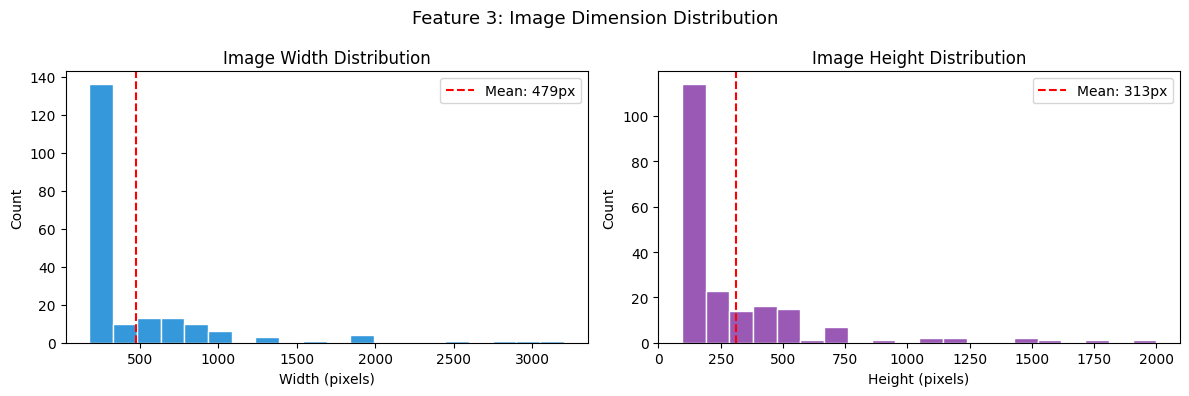


 Interpretation: Images vary in size (avg 479x313px).
Resizing all images to 224x224 during preprocessing standardizes input for VGG16.
This normalization step is critical for consistent model performance.


In [14]:
# Feature 3: Image Size Distribution
widths, heights = [], []

# Use all_counts and BASE_DIR since TRAIN_DIR is None and train_counts is not defined
for class_name in all_counts.keys():
    class_path = os.path.join(BASE_DIR, class_name)
    # Sample a maximum of 50 images per class to avoid excessive processing for large datasets
    for img_file in random.sample(os.listdir(class_path), min(50, len(os.listdir(class_path)))):
        try:
            img = Image.open(os.path.join(class_path, img_file))
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except Exception:
            pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(widths, bins=20, color='#3498db', edgecolor='white')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Count')
axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}px')
axes[0].legend()

axes[1].hist(heights, bins=20, color='#9b59b6', edgecolor='white')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Count')
axes[1].axvline(np.mean(heights), color='red', linestyle='--', label=f'Mean: {np.mean(heights):.0f}px')
axes[1].legend()

plt.suptitle('Feature 3: Image Dimension Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('image_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n Interpretation: Images vary in size (avg {np.mean(widths):.0f}x{np.mean(heights):.0f}px).')
print('Resizing all images to 224x224 during preprocessing standardizes input for VGG16.')
print('This normalization step is critical for consistent model performance.')

## 4. Data Preprocessing

In [17]:
# First, let's redefine NUM_CLASSES correctly
NUM_CLASSES = len(all_counts)

# Create train, validation, and test directories
TRAIN_SPLIT_DIR = '/content/data/dataset/train'
VAL_SPLIT_DIR   = '/content/data/dataset/validation'
TEST_SPLIT_DIR  = '/content/data/dataset/test'

# Ensure these directories are clean before splitting
!rm -rf {TRAIN_SPLIT_DIR} {VAL_SPLIT_DIR} {TEST_SPLIT_DIR}

for d in [TRAIN_SPLIT_DIR, VAL_SPLIT_DIR, TEST_SPLIT_DIR]:
    os.makedirs(d, exist_ok=True)
    for class_name in all_counts.keys():
        os.makedirs(os.path.join(d, class_name), exist_ok=True)

# Perform the train-validation-test split
for class_name in all_counts.keys():
    class_path = os.path.join(BASE_DIR, class_name)
    images = os.listdir(class_path)
    random.shuffle(images)

    train_split_idx = int(0.7 * len(images)) # 70% for training
    val_split_idx   = int(0.85 * len(images)) # 15% for validation, 15% for test

    train_images = images[:train_split_idx]
    val_images   = images[train_split_idx:val_split_idx]
    test_images  = images[val_split_idx:]

    for img_name in train_images:
        os.symlink(os.path.join(class_path, img_name), os.path.join(TRAIN_SPLIT_DIR, class_name, img_name))
    for img_name in val_images:
        os.symlink(os.path.join(class_path, img_name), os.path.join(VAL_SPLIT_DIR, class_name, img_name))
    for img_name in test_images:
        os.symlink(os.path.join(class_path, img_name), os.path.join(TEST_SPLIT_DIR, class_name, img_name))

print('Dataset split and symlinked successfully!')

# Now, set TRAIN_DIR and TEST_DIR to the new split directories
TRAIN_DIR = TRAIN_SPLIT_DIR
TEST_DIR  = TEST_SPLIT_DIR
VAL_DIR   = VAL_SPLIT_DIR

# Option 1: Remove black corners
def remove_black_corners(img_array):
    """Replace black triangular corner pixels with white."""
    mask = (img_array[:,:,0] < 30) & \
           (img_array[:,:,1] < 30) & \
           (img_array[:,:,2] < 30)
    img_array[mask] = [255, 255, 255]
    return img_array

# Options 1, 2, 3: Better augmentation + black corner removal
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='constant',
    cval=255,
    validation_split=0.2, # This will be used for validation data *from* the training data if VAL_DIR is not separate
    preprocessing_function=remove_black_corners
)

# For validation and test sets, only rescale and apply preprocessing function
val_test_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    preprocessing_function=remove_black_corners
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    # subset='training', # No need for subset here as we have separate TRAIN_DIR and VAL_DIR
    seed=SEED,
    shuffle=True,
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR, # Use the separate validation directory
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    # subset='validation', # No need for subset here
    seed=SEED,
    shuffle=False,
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)

class_names = list(train_generator.class_indices.keys())
print(f'Classes: {class_names}')
print(f'Training batches:   {len(train_generator)}')
print(f'Validation batches: {len(val_generator)}')
print(f'Test batches:       {len(test_generator)}')


Dataset split and symlinked successfully!
Found 786 images belonging to 4 classes.
Found 169 images belonging to 4 classes.
Found 170 images belonging to 4 classes.
Classes: ['Cloudy', 'Rain', 'Shine', 'Sunrise']
Training batches:   25
Validation batches: 6
Test batches:       6


## 5. Model Creation — VGG16 Transfer Learning

In [18]:
def build_model(num_classes=NUM_CLASSES):
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(*IMG_SIZE, 3)
    )
    base_model.trainable = False

    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,112,772 (57.65 MB)

 Trainable params: 396,548 (1.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

## 6. Model Training

In [20]:
# Callbacks
os.makedirs('models', exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='models/weather_model_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print('Starting Phase 1: Feature Extraction (frozen base)...')
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Starting Phase 1: Feature Extraction (frozen base)...
Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - accuracy: 0.5344 - loss: 1.2014 
Epoch 1: val_accuracy improved from None to 0.68639, saving model to models/weather_model_best.keras

Epoch 1: finished saving model to models/weather_model_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 694s 28s/step - accuracy: 0.5687 - loss: 1.1393 - val_accuracy: 0.6864 - val_loss: 1.2425 - learning_rate: 1.0000e-04
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - accuracy: 0.6467 - loss: 0.8996 
Epoch 2: val_accuracy improved from 0.68639 to 0.75148, saving model to models/weather_model_best.keras

Epoch 2: finished saving model to models/weather_model_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 700s 28s/step - accuracy: 0.6387 - loss: 0.9418 - val_accuracy: 0.7515 - val_loss: 1.1718 - learning_rate: 1.0000e-04
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - accuracy: 0.6729 - loss: 0.8259 
Epoch 3: val_accuracy improved from 0.75148 to 0.76923, saving

In [31]:
# Phase 2: Fine-tuning — unfreeze last 8 VGG16 layers
print('Starting Phase 2: Fine-tuning (partial unfreeze)...')

base_model = model.layers[0]
base_model.trainable = True

# Freeze all layers except last 8
for layer in base_model.layers[:-8]:
    layer.trainable = False

print(f'Trainable layers: {sum(1 for l in base_model.layers if l.trainable)}')

# Recompile with lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='models/weather_model_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

history_finetune = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks_ft,
    verbose=1
)

Starting Phase 2: Fine-tuning (partial unfreeze)...
Trainable layers: 8
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 42s/step - accuracy: 0.9440 - loss: 0.2236 
Epoch 1: val_accuracy improved from None to 0.95266, saving model to models/weather_model_best.keras

Epoch 1: finished saving model to models/weather_model_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 1182s 47s/step - accuracy: 0.9440 - loss: 0.2107 - val_accuracy: 0.9527 - val_loss: 0.1711 - learning_rate: 1.0000e-05
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 42s/step - accuracy: 0.9434 - loss: 0.1781 
Epoch 2: val_accuracy improved from 0.95266 to 0.97633, saving model to models/weather_model_best.keras

Epoch 2: finished saving model to models/weather_model_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 1189s 48s/step - accuracy: 0.9313 - loss: 0.1934 - val_accuracy: 0.9763 - val_loss: 0.0911 - learning_rate: 1.0000e-05
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 42s/step - accuracy: 0.9400 - loss: 0.1741 
Epoch 3: val_accuracy did not improve from

## Training Curves

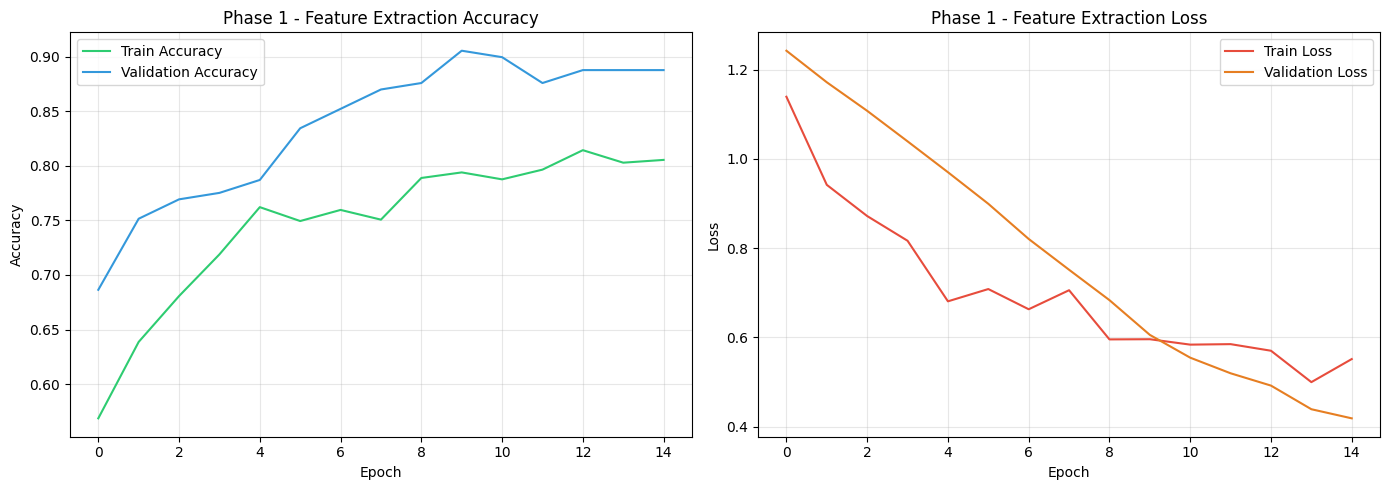

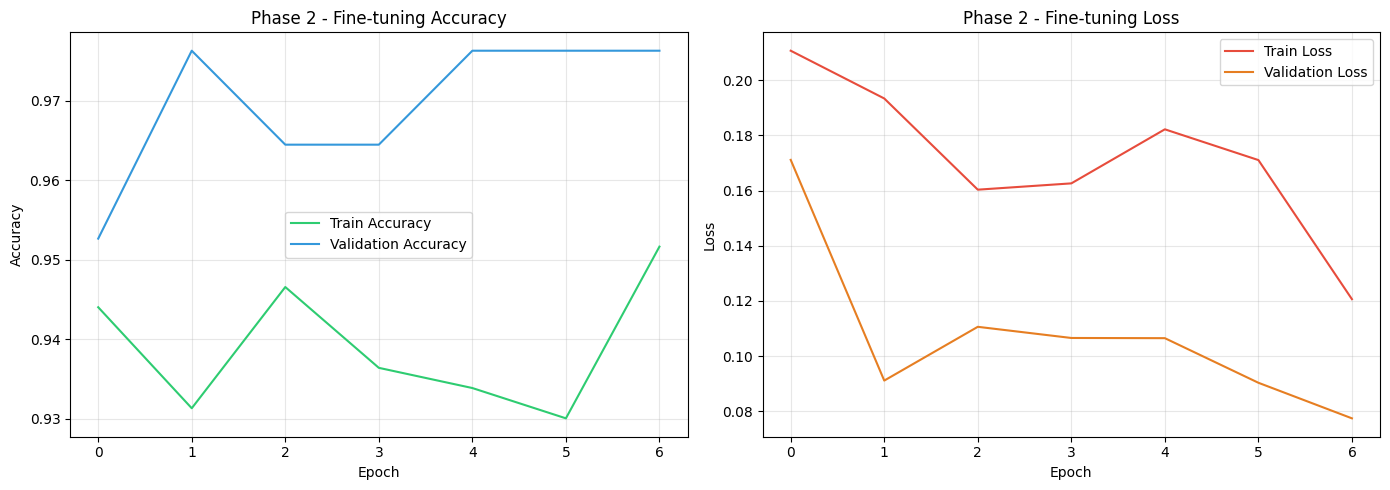

In [32]:
def plot_training_history(history, title_prefix=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='#2ecc71')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy',  color='#3498db')
    axes[0].set_title(f'{title_prefix} Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss',     color='#e74c3c')
    axes[1].plot(history.history['val_loss'], label='Validation Loss', color='#e67e22')
    axes[1].set_title(f'{title_prefix} Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'training_curves_{title_prefix.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

plot_training_history(history, 'Phase 1 - Feature Extraction')
plot_training_history(history_finetune, 'Phase 2 - Fine-tuning')

## Model Evaluation

In [33]:
# Test Set Evaluation
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f'\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print(f'Test Loss:     {test_loss:.4f}')

6/6 ━━━━━━━━━━━━━━━━━━━━ 122s 20s/step - accuracy: 0.9706 - loss: 0.1796

Test Accuracy: 0.9706 (97.06%)
Test Loss:     0.1796


In [34]:
# Predictions
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_generator.classes

# Classification Report
print('\nClassification Report:')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

# Aggregate Metrics
print('\nAggregate Metrics:')
print(f'  Accuracy:  {accuracy_score(y_true, y_pred):.4f}')
print(f'  Precision: {precision_score(y_true, y_pred, average="weighted"):.4f}')
print(f'  Recall:    {recall_score(y_true, y_pred, average="weighted"):.4f}')
print(f'  F1 Score:  {f1_score(y_true, y_pred, average="weighted"):.4f}')

5/6 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 121s 19s/step

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.98      0.96      0.97        45
        Rain       0.97      1.00      0.99        33
       Shine       0.93      1.00      0.96        38
     Sunrise       1.00      0.94      0.97        54

    accuracy                           0.97       170
   macro avg       0.97      0.98      0.97       170
weighted avg       0.97      0.97      0.97       170


Aggregate Metrics:
  Accuracy:  0.9706
  Precision: 0.9719
  Recall:    0.9706
  F1 Score:  0.9706


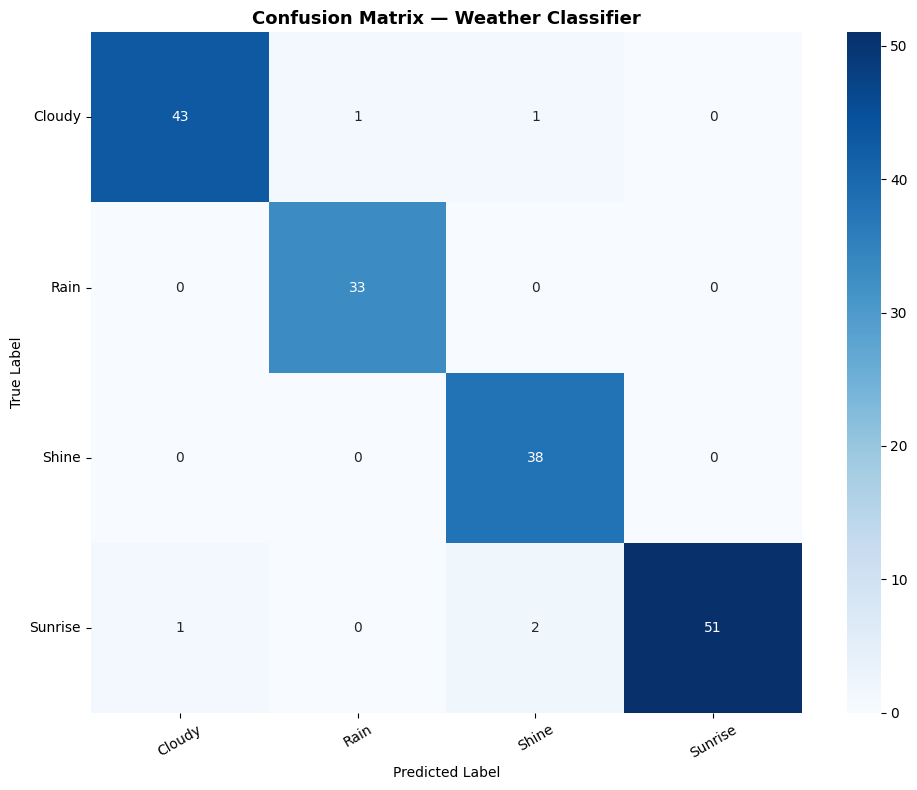

In [35]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix — Weather Classifier', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

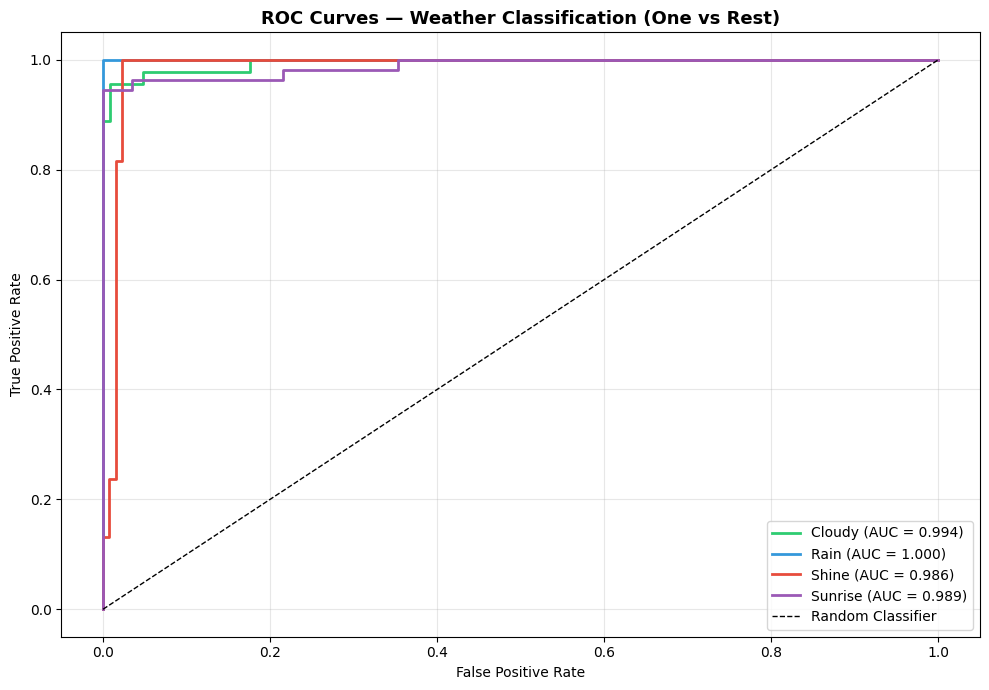

In [36]:
# ROC Curves (One-vs-Rest)
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(10, 7))
colors_roc = ['#2ecc71','#3498db','#e74c3c','#9b59b6','#f39c12','#1abc9c']

for i, (cls, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    auc_score   = roc_auc_score(y_true_bin[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC = {auc_score:.3f})')

plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Weather Classification (One vs Rest)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

## Model Testing — Single Image Prediction

Testing with image from class: Cloudy


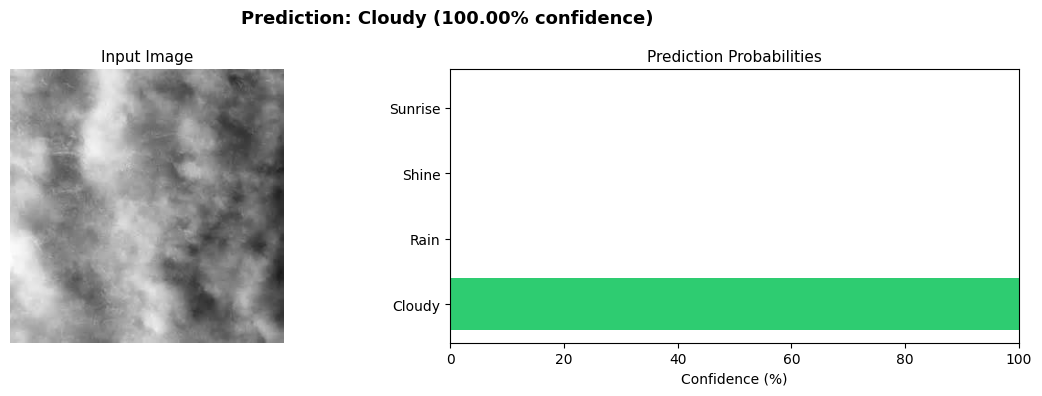

In [37]:
def predict_image(model, image_path, class_names, img_size=(224, 224)):
    """Predict weather class for a single image."""
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize(img_size)
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)
    predicted_idx   = np.argmax(predictions[0])
    predicted_class = class_names[predicted_idx]
    confidence       = predictions[0][predicted_idx] * 100

    # Display result
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(img)
    axes[0].set_title(f'Input Image', fontsize=11)
    axes[0].axis('off')

    colors_bar = ['#2ecc71' if p == max(predictions[0]) else '#bdc3c7' for p in predictions[0]]
    axes[1].barh(class_names, predictions[0] * 100, color=colors_bar)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title('Prediction Probabilities', fontsize=11)
    axes[1].set_xlim(0, 100)

    plt.suptitle(f'Prediction: {predicted_class} ({confidence:.2f}% confidence)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return predicted_class, confidence, predictions[0].tolist()

# Test with a sample image
sample_class = random.choice(class_names)
sample_dir   = os.path.join(TEST_DIR, sample_class)
sample_img   = os.path.join(sample_dir, random.choice(os.listdir(sample_dir)))

print(f'Testing with image from class: {sample_class}')
pred_class, confidence, probs = predict_image(model, sample_img, class_names)

## Model Retraining Setup

In [38]:
def retrain_model(model, new_data_dir, epochs=5, learning_rate=1e-5):
    """
    Retrain the weather model on new uploaded data.
    This function is called by the FastAPI /retrain endpoint.

    Args:
        model: Existing Keras model
        new_data_dir: Directory containing new training images (organized by class)
        epochs: Number of retraining epochs
        learning_rate: Learning rate for retraining

    Returns:
        dict: Retraining metrics
    """
    retrain_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        horizontal_flip=True,
        validation_split=0.2
    )

    retrain_gen = retrain_datagen.flow_from_directory(
        new_data_dir,
        target_size=IMG_SIZE,
        batch_size=16,
        class_mode='categorical',
        subset='training',
        seed=SEED
    )

    retrain_val_gen = retrain_datagen.flow_from_directory(
        new_data_dir,
        target_size=IMG_SIZE,
        batch_size=16,
        class_mode='categorical',
        subset='validation',
        seed=SEED
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    retrain_history = model.fit(
        retrain_gen,
        epochs=epochs,
        validation_data=retrain_val_gen,
        verbose=1
    )

    # Save updated model
    model.save('models/weather_model_retrained.h5')
    print('Model retrained and saved to models/weather_model_retrained.h5')

    return {
        'final_train_accuracy': retrain_history.history['accuracy'][-1],
        'final_val_accuracy':   retrain_history.history['val_accuracy'][-1],
        'epochs_run': len(retrain_history.history['accuracy'])
    }

print('Retrain function defined and ready.')
print('This will be triggered via the FastAPI /retrain endpoint in production.')

Retrain function defined and ready.
This will be triggered via the FastAPI /retrain endpoint in production.


## Save Final Model

In [39]:
import json
import os

SAVE_DIR = '/content/drive/MyDrive/MLPOS/models'
os.makedirs(SAVE_DIR, exist_ok=True)

model.save(f'{SAVE_DIR}/weather_model_final.keras')

with open(f'{SAVE_DIR}/class_names.json', 'w') as f:
    json.dump(class_names, f)

print('Saved to Drive!')
print(f'  → {SAVE_DIR}/weather_model_final.keras')

Saved to Drive!
  → /content/drive/MyDrive/MLPOS/models/weather_model_final.keras
